# Network and Community Metric Evolution

This notebook visualizes network and community metrics from the phase-one outputs. It does not use lifecycle event metrics, because event classification belongs to the next phase.


In [1]:
from pathlib import Path
import sys

def find_project_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "dataset" / "email-Eu-core-temporal.txt").exists():
            return candidate
    raise FileNotFoundError("Could not find dataset/email-Eu-core-temporal.txt in this folder or its parents.")

PROJECT_DIR = find_project_root()
CODE_DIR = Path.cwd().resolve()
if not (CODE_DIR / "graph_matching.py").exists():
    CODE_DIR = PROJECT_DIR / "code" / "graph-matching"

sys.path.insert(0, str(CODE_DIR))
PROJECT_DIR, CODE_DIR


(PosixPath('/Users/maha_personal/Uni/SS 26/IDP'),
 PosixPath('/Users/maha_personal/Uni/SS 26/IDP/code/graph-matching'))

In [2]:
from types import SimpleNamespace

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display

from graph_matching import load_edges, run_approach
from visualize_metrics import compute_metrics_for_approach

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

DATA_PATH = PROJECT_DIR / "dataset" / "email-Eu-core-temporal.txt"
OUTPUT_DIR = CODE_DIR / "outputs" / "graph_matching"

DATA_PATH, OUTPUT_DIR


(PosixPath('/Users/maha_personal/Uni/SS 26/IDP/dataset/email-Eu-core-temporal.txt'),
 PosixPath('/Users/maha_personal/Uni/SS 26/IDP/code/graph-matching/outputs/graph_matching'))

In [3]:
def show_table(df, title=None, height=360):
    caption = f"<h3 style='margin: 8px 0'>{title}</h3>" if title else ""
    html = df.to_html(index=False, border=0, classes="metric-table")
    display(HTML(f"""
    {caption}
    <div style="max-height:{height}px; overflow:auto; border:1px solid #ddd; padding:8px; margin:8px 0 18px 0;">
      <style>
        .metric-table {{ border-collapse: collapse; width: max-content; min-width: 100%; font-size: 12px; }}
        .metric-table th {{ position: sticky; top: 0; background: #f8fafc; z-index: 1; }}
        .metric-table th, .metric-table td {{ border: 1px solid #e5e7eb; padding: 4px 8px; white-space: nowrap; }}
      </style>
      {html}
    </div>
    """))

def plot_metric_grid(df, panels, title, figsize=(14, 8)):
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    for ax, (panel_title, metrics, ylabel) in zip(axes, panels):
        for metric in metrics:
            ax.plot(df["snapshot_index"], df[metric], marker="o", linewidth=2, label=metric)
        ax.set_title(panel_title)
        ax.set_xlabel("Snapshot index")
        if ylabel:
            ax.set_ylabel(ylabel)
        ax.legend(loc="best", fontsize=8)
    fig.suptitle(title, fontsize=15, y=1.02)
    fig.tight_layout()
    plt.show()


## Ensure Graph Matching Results Exist

Run this cell if needed to regenerate the original graph-matching CSV outputs.


In [4]:
edges = load_edges(DATA_PATH, cutoff_days=500)

for approach_name in ["cumulative", "interval", "overlap"]:
    run_approach(
        edges=edges,
        approach=approach_name,
        output_dir=OUTPUT_DIR,
        cutoff_days=500,
        snapshot_days=50,
        num_snapshots=10,
        overlap_fraction=0.5,
        seed=42,
        resolution=1.0,
        min_community_size=3,
        match_threshold=0.5,
    )

OUTPUT_DIR


PosixPath('/Users/maha_personal/Uni/SS 26/IDP/code/graph-matching/outputs/graph_matching')

In [5]:
metric_args = SimpleNamespace(
    data=DATA_PATH,
    results=OUTPUT_DIR,
    cutoff_days=500,
    snapshot_days=50,
    num_snapshots=10,
    overlap_fraction=0.5,
)

metrics_by_approach = {}
for approach in ["cumulative", "interval", "overlap"]:
    network_metrics, community_metrics = compute_metrics_for_approach(metric_args, approach)
    metrics_by_approach[approach] = (network_metrics, community_metrics)
    show_table(network_metrics, title=f"{approach.capitalize()} Approach - Network Metrics")
    show_table(community_metrics, title=f"{approach.capitalize()} Approach - Community Metrics")

approach = "interval"
network_metrics, community_metrics = metrics_by_approach[approach]


approach,snapshot_index,snapshot_label,start_day,end_day,temporal_edges,nodes,weighted_edges,edge_weight_sum,density,transitivity,avg_clustering,connected_components,largest_component_nodes,largest_component_share,avg_degree,avg_weighted_degree,modularity
cumulative,0,days_0_50,0.0,50.0,28517,738,4361,28517.0,0.016036,0.206412,0.313749,3,734,0.99458,11.818428,77.281843,0.686157
cumulative,1,days_0_100,0.0,100.0,52291,789,6276,52291.0,0.020189,0.227214,0.339790,1,789,1.00000,15.908745,132.550063,0.671096
cumulative,2,days_0_150,0.0,150.0,82986,816,7753,82986.0,0.023316,0.237740,0.355547,1,816,1.00000,19.002451,203.397059,0.674953
cumulative,3,days_0_200,0.0,200.0,114304,838,9064,114304.0,0.025845,0.243673,0.362550,1,838,1.00000,21.632458,272.801909,0.669478
cumulative,4,days_0_250,0.0,250.0,154019,857,10456,154019.0,0.028506,0.250844,0.376434,1,857,1.00000,24.401400,359.437573,0.673182
cumulative,5,days_0_300,0.0,300.0,174366,873,11180,174366.0,0.029373,0.252125,0.383281,1,873,1.00000,25.612829,399.463918,0.672134
cumulative,6,days_0_350,0.0,350.0,205152,885,12116,205152.0,0.030974,0.254737,0.387321,1,885,1.00000,27.380791,463.620339,0.663901
cumulative,7,days_0_400,0.0,400.0,242800,922,13195,242800.0,0.031078,0.259596,0.396419,1,922,1.00000,28.622560,526.681128,0.664438
cumulative,8,days_0_450,0.0,450.0,264051,959,14160,264051.0,0.030825,0.259811,0.394285,1,959,1.00000,29.530761,550.679875,0.667610
cumulative,9,days_0_500,0.0,500.0,307868,977,15462,307868.0,0.032430,0.265138,0.402047,1,977,1.00000,31.651996,630.231320,0.679959


approach,snapshot_index,snapshot_label,start_day,end_day,temporal_edges,communities,total_community_memberships,mean_community_size,median_community_size,max_community_size,min_community_size,largest_community_share,effective_communities,mean_internal_density,median_internal_density
cumulative,0,days_0_50,0.0,50.0,28517,15,734,48.933333,50.0,110,6,0.149864,12.628745,0.186696,0.123034
cumulative,1,days_0_100,0.0,100.0,52291,13,785,60.384615,51.0,155,24,0.197452,11.025315,0.184304,0.152582
cumulative,2,days_0_150,0.0,150.0,82986,13,814,62.615385,57.0,177,5,0.217445,10.265386,0.236940,0.166500
cumulative,3,days_0_200,0.0,200.0,114304,13,836,64.307692,61.0,169,9,0.202153,10.931594,0.209285,0.193662
cumulative,4,days_0_250,0.0,250.0,154019,12,855,71.250000,59.5,177,22,0.207018,9.891076,0.246160,0.204946
cumulative,5,days_0_300,0.0,300.0,174366,12,871,72.583333,69.0,183,7,0.210103,9.991685,0.226299,0.186119
cumulative,6,days_0_350,0.0,350.0,205152,13,883,67.923077,64.0,177,8,0.200453,10.722606,0.242326,0.203959
cumulative,7,days_0_400,0.0,400.0,242800,13,920,70.769231,60.0,196,10,0.213043,10.503865,0.237392,0.222222
cumulative,8,days_0_450,0.0,450.0,264051,13,957,73.615385,66.0,179,10,0.187043,10.996335,0.215165,0.222222
cumulative,9,days_0_500,0.0,500.0,307868,15,977,65.133333,60.0,200,10,0.204708,11.534667,0.270532,0.225614


approach,snapshot_index,snapshot_label,start_day,end_day,temporal_edges,nodes,weighted_edges,edge_weight_sum,density,transitivity,avg_clustering,connected_components,largest_component_nodes,largest_component_share,avg_degree,avg_weighted_degree,modularity
interval,0,days_0_50,0.0,50.0,28517,738,4361,28517.0,0.016036,0.206412,0.313749,3,734,0.994580,11.818428,77.281843,0.686157
interval,1,days_50_100,50.0,100.0,23774,732,4427,23774.0,0.016547,0.213539,0.335584,1,732,1.000000,12.095628,64.956284,0.673969
interval,2,days_100_150,100.0,150.0,30695,723,4434,30695.0,0.016988,0.208110,0.338300,1,723,1.000000,12.265560,84.910097,0.693649
interval,3,days_150_200,150.0,200.0,31318,742,4632,31318.0,0.016849,0.205056,0.327785,4,734,0.989218,12.485175,84.415094,0.672104
interval,4,days_200_250,200.0,250.0,39715,746,5092,39715.0,0.018324,0.209732,0.349960,1,746,1.000000,13.651475,106.474531,0.692159
interval,5,days_250_300,250.0,300.0,20347,710,3753,20347.0,0.014911,0.215261,0.314706,2,707,0.995775,10.571831,57.315493,0.712107
interval,6,days_300_350,300.0,350.0,30786,724,4708,30786.0,0.017988,0.212228,0.331798,2,719,0.993094,13.005525,85.044199,0.697133
interval,7,days_350_400,350.0,400.0,37648,766,5092,37648.0,0.017379,0.220072,0.340444,1,766,1.000000,13.295039,98.297650,0.666616
interval,8,days_400_450,400.0,450.0,21251,779,4429,21251.0,0.014616,0.202472,0.306195,1,779,1.000000,11.370988,54.559692,0.686190
interval,9,days_450_500,450.0,500.0,43817,804,5774,43817.0,0.017887,0.217138,0.349076,4,796,0.990050,14.363184,108.997512,0.699998


approach,snapshot_index,snapshot_label,start_day,end_day,temporal_edges,communities,total_community_memberships,mean_community_size,median_community_size,max_community_size,min_community_size,largest_community_share,effective_communities,mean_internal_density,median_internal_density
interval,0,days_0_50,0.0,50.0,28517,15,734,48.933333,50.0,110,6,0.149864,12.628745,0.186696,0.123034
interval,1,days_50_100,50.0,100.0,23774,14,728,52.000000,53.0,81,17,0.111264,13.004176,0.143134,0.138696
interval,2,days_100_150,100.0,150.0,30695,14,721,51.500000,48.0,100,5,0.138696,11.586722,0.190677,0.185109
interval,3,days_150_200,150.0,200.0,31318,14,736,52.571429,49.5,155,4,0.210598,10.474637,0.224685,0.163439
interval,4,days_200_250,200.0,250.0,39715,15,746,49.733333,44.0,109,3,0.146113,12.470006,0.207638,0.146934
interval,5,days_250_300,250.0,300.0,20347,16,710,44.375000,39.5,83,3,0.116901,13.875070,0.201106,0.147036
interval,6,days_300_350,300.0,350.0,30786,15,724,48.266667,51.0,88,5,0.121547,12.518530,0.201227,0.136213
interval,7,days_350_400,350.0,400.0,37648,14,764,54.571429,51.5,99,6,0.129581,12.314294,0.172358,0.157541
interval,8,days_400_450,400.0,450.0,21251,11,777,70.636364,90.0,124,14,0.159588,9.559760,0.146360,0.113018
interval,9,days_450_500,450.0,500.0,43817,16,800,50.000000,38.5,104,4,0.130000,13.174231,0.228979,0.164717


approach,snapshot_index,snapshot_label,start_day,end_day,temporal_edges,nodes,weighted_edges,edge_weight_sum,density,transitivity,avg_clustering,connected_components,largest_component_nodes,largest_component_share,avg_degree,avg_weighted_degree,modularity
overlap,0,days_0_50,0.0,50.0,28517,738,4361,28517.0,0.016036,0.206412,0.313749,3,734,0.994580,11.818428,77.281843,0.686157
overlap,1,days_25_75,25.0,75.0,23794,739,4297,23794.0,0.015758,0.206621,0.332335,2,737,0.997294,11.629229,64.395129,0.692542
overlap,2,days_50_100,50.0,100.0,23774,732,4427,23774.0,0.016547,0.213539,0.335584,1,732,1.000000,12.095628,64.956284,0.673969
overlap,3,days_75_125,75.0,125.0,28493,722,4475,28493.0,0.017193,0.211795,0.353434,1,722,1.000000,12.396122,78.927978,0.676033
overlap,4,days_100_150,100.0,150.0,30695,723,4434,30695.0,0.016988,0.208110,0.338300,1,723,1.000000,12.265560,84.910097,0.693649
overlap,5,days_125_175,125.0,175.0,32448,739,4547,32448.0,0.016675,0.211222,0.319044,2,737,0.997294,12.305819,87.815968,0.690707
overlap,6,days_150_200,150.0,200.0,31318,742,4632,31318.0,0.016849,0.205056,0.327785,4,734,0.989218,12.485175,84.415094,0.672104
overlap,7,days_175_225,175.0,225.0,31754,742,4794,31754.0,0.017438,0.202101,0.342106,2,738,0.994609,12.921833,85.590296,0.688486
overlap,8,days_200_250,200.0,250.0,39715,746,5092,39715.0,0.018324,0.209732,0.349960,1,746,1.000000,13.651475,106.474531,0.692159
overlap,9,days_225_275,225.0,275.0,35389,742,4918,35389.0,0.017889,0.208731,0.348609,1,742,1.000000,13.256065,95.388140,0.672138


approach,snapshot_index,snapshot_label,start_day,end_day,temporal_edges,communities,total_community_memberships,mean_community_size,median_community_size,max_community_size,min_community_size,largest_community_share,effective_communities,mean_internal_density,median_internal_density
overlap,0,days_0_50,0.0,50.0,28517,15,734,48.933333,50.0,110,6,0.149864,12.628745,0.186696,0.123034
overlap,1,days_25_75,25.0,75.0,23794,16,737,46.062500,47.0,115,7,0.156038,13.574789,0.181736,0.143315
overlap,2,days_50_100,50.0,100.0,23774,14,728,52.000000,53.0,81,17,0.111264,13.004176,0.143134,0.138696
overlap,3,days_75_125,75.0,125.0,28493,15,720,48.000000,48.0,97,10,0.134722,13.174929,0.178499,0.135897
overlap,4,days_100_150,100.0,150.0,30695,14,721,51.500000,48.0,100,5,0.138696,11.586722,0.190677,0.185109
overlap,5,days_125_175,125.0,175.0,32448,14,735,52.500000,47.5,136,19,0.185034,12.029277,0.186876,0.159091
overlap,6,days_150_200,150.0,200.0,31318,14,736,52.571429,49.5,155,4,0.210598,10.474637,0.224685,0.163439
overlap,7,days_175_225,175.0,225.0,31754,13,740,56.923077,53.0,109,4,0.147297,10.885353,0.197026,0.158187
overlap,8,days_200_250,200.0,250.0,39715,15,746,49.733333,44.0,109,3,0.146113,12.470006,0.207638,0.146934
overlap,9,days_225_275,225.0,275.0,35389,13,740,56.923077,55.0,130,19,0.175676,11.357747,0.185551,0.146341


## Network Metrics:

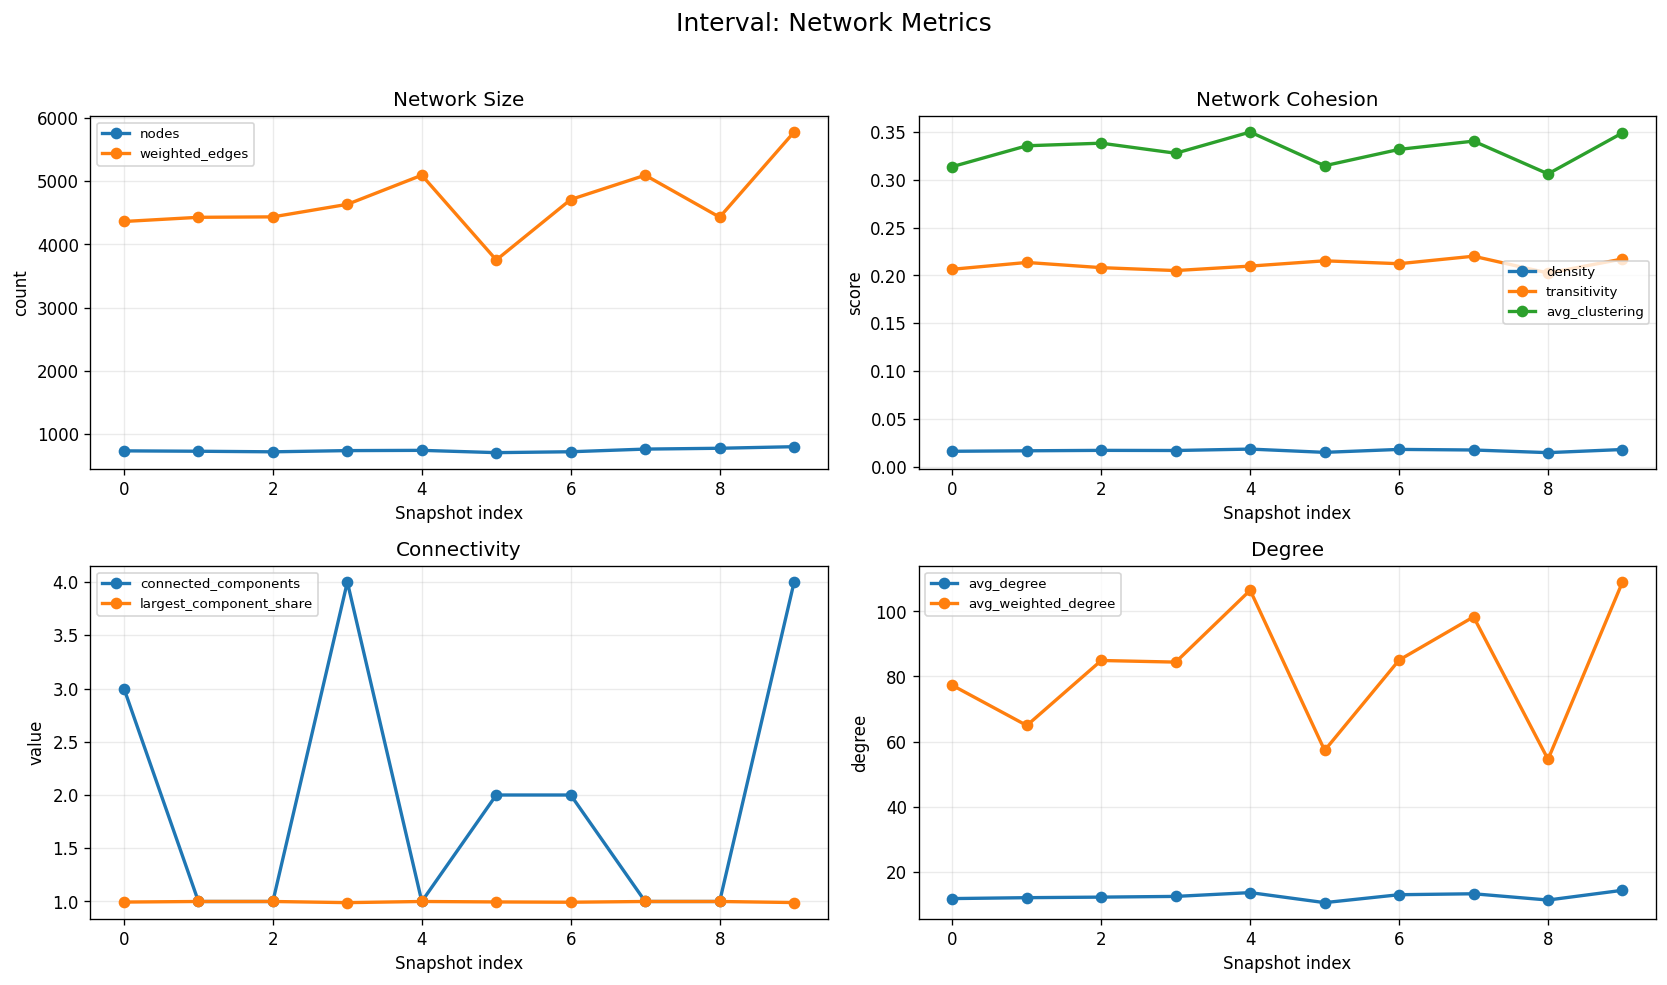

In [6]:
network_panels = [
    ("Network Size", ["nodes", "weighted_edges"], "count"),
    ("Network Cohesion", ["density", "transitivity", "avg_clustering"], "score"),
    ("Connectivity", ["connected_components", "largest_component_share"], "value"),
    ("Degree", ["avg_degree", "avg_weighted_degree"], "degree"),
]
plot_metric_grid(network_metrics, network_panels, f"{approach.title()}: Network Metrics")


## Community Metrics:

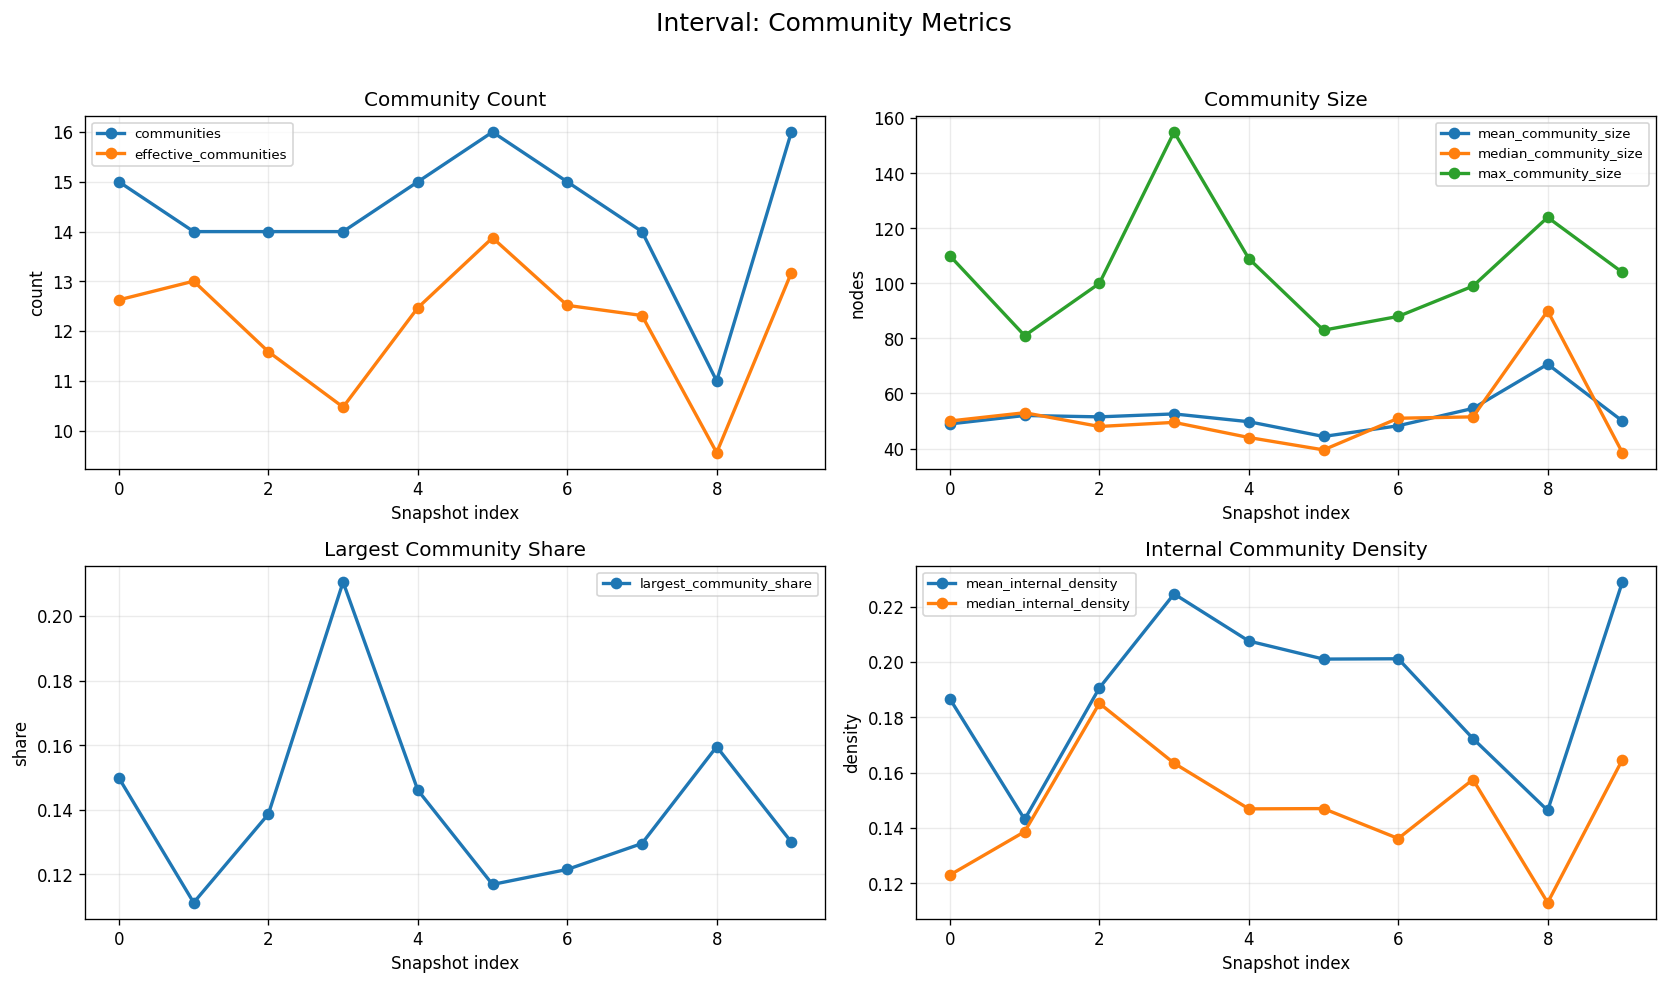

In [7]:
community_panels = [
    ("Community Count", ["communities", "effective_communities"], "count"),
    ("Community Size", ["mean_community_size", "median_community_size", "max_community_size"], "nodes"),
    ("Largest Community Share", ["largest_community_share"], "share"),
    ("Internal Community Density", ["mean_internal_density", "median_internal_density"], "density"),
]
plot_metric_grid(community_metrics, community_panels, f"{approach.title()}: Community Metrics")


## Approach Comparison

In [8]:
comparison_rows = []
for current_approach in ["cumulative", "interval", "overlap"]:
    net, comm = compute_metrics_for_approach(metric_args, current_approach)
    matches = pd.read_csv(OUTPUT_DIR / current_approach / "matches.csv")
    comparison_rows.append({
        "approach": current_approach,
        "snapshots": len(net),
        "mean_nodes": net["nodes"].mean(),
        "mean_edges": net["weighted_edges"].mean(),
        "mean_density": net["density"].mean(),
        "mean_transitivity": net["transitivity"].mean(),
        "mean_modularity": net["modularity"].mean(),
        "mean_communities": comm["communities"].mean(),
        "mean_community_size": comm["mean_community_size"].mean(),
        "matches": len(matches),
        "mean_jaccard": matches["jaccard"].mean(),
    })

comparison = pd.DataFrame(comparison_rows).round(4)
show_table(comparison, "Approach Comparison", height=220)


approach,snapshots,mean_nodes,mean_edges,mean_density,mean_transitivity,mean_modularity,mean_communities,mean_community_size,matches,mean_jaccard
cumulative,10,865.4000,10402.3000,0.0269,0.2457,0.6723,13.2000,65.7515,98,0.8435
interval,10,746.4000,4670.2000,0.0168,0.2110,0.6880,14.4000,52.2588,56,0.6458
overlap,19,745.5263,4656.5789,0.0167,0.2108,0.6887,14.2632,52.5722,158,0.7245
